## **Task 1: Data Loading, EDA & Preprocessing**

#### 1.1 Load the dataset

In [1]:
from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer(as_frame=True)

In [3]:
X = data.data

In [4]:
y = data.target

In [5]:
X.shape

(569, 30)

In [7]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [8]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


---
Loaded the Breast Cancer Wisconsin dataset using load_breast_cancer(as_frame=True). The dataset contains 569 samples across 30 continuous numeric features with zero missing values. The target variable exhibits a mild class imbalance: 212 Malignant ($0$) vs. 357 Benign ($1$). 

#### 1.2 Class distribution plot

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

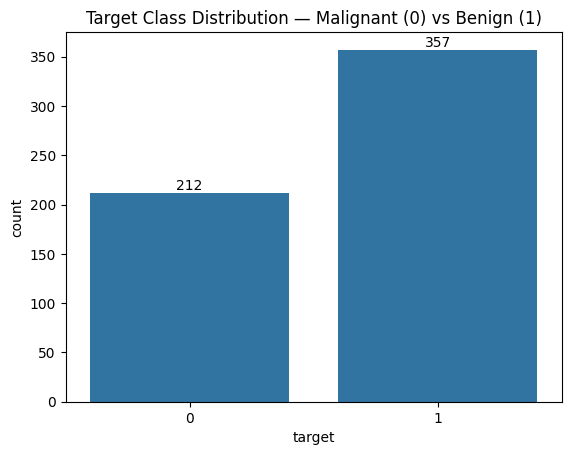

In [11]:
ax = sns.countplot(x=y)
plt.title('Target Class Distribution — Malignant (0) vs Benign (1)')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
plt.show()

---
Created a count plot showing the target distribution ($37.3\%$ Malignant vs. $62.7\%$ Benign). This mild imbalance is acceptable for standard binary classification algorithms without needing synthetic resampling (like SMOTE), though stratified splitting should be used to maintain class proportions across train and test sets.

#### 1.3 Feature correlation heatmap 

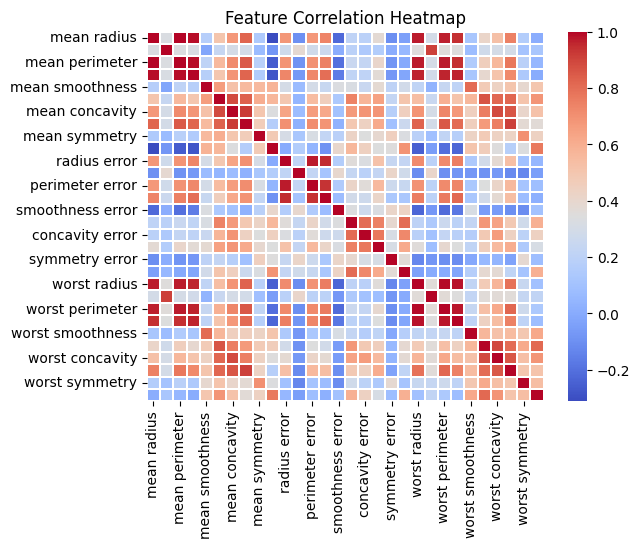

In [16]:
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.show()

##### 1. Highly Correlated Feature Pairs
Based on the heatmap, the following feature pairs exhibit near-perfect positive correlation due to underlying geometric and physical relationships:
* **`mean radius` and `mean perimeter`** ($\approx 0.997$ correlation): Perimeter scales linearly with radius ($P \approx 2\pi r$), making these features almost redundant[cite: 1].
* **`mean radius` and `mean area`** ($\approx 0.987$ correlation): Area scales quadratically with radius ($A \approx \pi r^2$), creating a strong monotonic relationship[cite: 1].
* **`mean concavity` and `mean concave points`** ($\approx 0.921$ correlation): The overall severity of concave regions strongly correlates with the count of concave portions along the cell nucleus boundary[cite: 1].

---

##### 2. Why Inter-Feature Correlation Does Not Harm Neural Networks
Unlike linear models, neural networks handle highly correlated (collinear) features without issue:

* **Linear Model Sensitivity:** Traditional linear models rely on matrix inversion or distinct parameter estimation[cite: 1]. High multicollinearity causes unstable coefficient estimates, inflated standard errors, and unreliable feature importance[cite: 1].
* **Distributed Representation:** Neural networks combine input features non-linearly across hidden layer neurons:
  $$\text{Neuron Output} = \sigma\left(\sum w_i x_i + b\right)$$
  The network simply distributes weight values across correlated inputs without breaking optimization.
* **Gradient-Based Optimization:** Training relies on iterative backpropagation (e.g., Adam, SGD) rather than direct matrix inversion, avoiding numerical instability[cite: 1].
* **Feature Extraction:** Correlated inputs provide redundant signals that non-linear activation functions can combine to extract higher-level abstract features[cite: 1].
---

#### 1.4 Train / test split

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [21]:
y_train.value_counts()

target
1    285
0    170
Name: count, dtype: int64

In [22]:
y_test.value_counts()

target
1    72
0    42
Name: count, dtype: int64

The stratify parameter preserved the ~63/37 class ratio in both splits. 

#### 1.5 Apply StandardScaler

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [27]:
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)